# Tugas Besar 1 — IF3270 Pembelajaran Mesin
## Pengujian Feedforward Neural Network (FFNN) From Scratch

## 1. Setup & Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import random
from nn import FFNN

random.seed(42)
np.random.seed(42)

## 2. Preprocessing Dataset

### 2.1 Load Dataset

In [2]:
df = pd.read_csv('../data/datasetml_2026.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


### 2.2 Explorasi Data

In [3]:
print(df.info())
print('\nValue Counts Target')
print(df['placement_status'].value_counts())
print('\nMissing Values')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB
None

Value Counts Target
placement_status
Placed        6153
Not Placed 

### 2.3 Encoding & Feature Engineering

In [4]:
# One-hot
df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head()

Shape after encoding: (10000, 24)


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,placement_status,college_tier_Tier 2,college_tier_Tier 3,country_Germany,...,university_ranking_band_Top 100,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,7.397371,1,2,53.574150,64.177062,5.481450,1,True,False,False,...,False,False,False,False,True,False,False,False,False,False
1,6.889389,0,1,60.687750,88.346052,4.625099,1,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,7.518151,0,2,64.568750,69.493171,5.227939,1,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,8.218424,0,3,73.461500,78.204854,5.150674,1,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,6.812677,1,4,86.518121,44.680881,3.888824,1,True,False,False,...,False,False,False,False,True,False,False,False,False,False


### 2.4 Split & Normalize

In [5]:
X = df_encoded.drop('placement_status', axis=1).values
y = df_encoded['placement_status'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split: 80:20 train val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_list = X_train.tolist()
X_val_list = X_val.tolist()
y_train_list = [[yi] for yi in y_train.tolist()]
y_val_list = [[yi] for yi in y_val.tolist()]

n_features = X_train.shape[1]
print(f'Features: {n_features}')
print(f'Train: {len(X_train_list)}, Val: {len(X_val_list)}')
print(f'Class distribution (train): {sum(y_train)}/{len(y_train)} placed')

Features: 23
Train: 8000, Val: 2000
Class distribution (train): 4922/8000 placed


## 3. Helper Functions

In [6]:
def plot_loss_history(history, title='Training & Validation Loss'):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    if history['val_loss'][0] is not None:
        plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X, y_true, label=''):
    preds = model.predict(X)
    y_pred = [1 if p[0] > 0.5 else 0 for p in preds]
    acc = accuracy_score(y_true, y_pred)
    print(f'{label} Accuracy: {acc:.4f}')
    return acc, y_pred

def train_and_evaluate(model, X_train, y_train, X_val, y_val, epochs=10, lr=0.01, batch_size=64, loss_fn='bce', optimizer='sgd', verbose=1, reg_type=None, reg_lambda=0.0, title='Model'):
    history = model.fit(X_train, y_train, epochs=epochs, learning_rate=lr, batch_size=batch_size, loss_fn=loss_fn, optimizer=optimizer, X_val=X_val, y_val=y_val, verbose=verbose, reg_type=reg_type, reg_lambda=reg_lambda)
    plot_loss_history(history, title=f'{title} - Loss')
    train_acc, _ = evaluate_model(model, X_train, [y[0] for y in y_train], label=f'{title} Train')
    val_acc, _ = evaluate_model(model, X_val, [y[0] for y in y_val], label=f'{title} Val')
    return history, train_acc, val_acc

## 4. Eksperimen 1: Pengaruh Depth & Width

### 4.1 Variasi Width (Depth Tetap = 3 hidden layers)


Width 8
Epoch 1/100 | Train Loss: 0.6647 | Val Loss: 0.6619
Epoch 2/100 | Train Loss: 0.6543 | Val Loss: 0.6520
Epoch 3/100 | Train Loss: 0.6422 | Val Loss: 0.6402
Epoch 4/100 | Train Loss: 0.6265 | Val Loss: 0.6236
Epoch 5/100 | Train Loss: 0.6061 | Val Loss: 0.6043
Epoch 6/100 | Train Loss: 0.5838 | Val Loss: 0.5844
Epoch 7/100 | Train Loss: 0.5627 | Val Loss: 0.5672
Epoch 8/100 | Train Loss: 0.5451 | Val Loss: 0.5534
Epoch 9/100 | Train Loss: 0.5318 | Val Loss: 0.5433
Epoch 10/100 | Train Loss: 0.5227 | Val Loss: 0.5367
Epoch 11/100 | Train Loss: 0.5165 | Val Loss: 0.5314
Epoch 12/100 | Train Loss: 0.5119 | Val Loss: 0.5273
Epoch 13/100 | Train Loss: 0.5084 | Val Loss: 0.5242
Epoch 14/100 | Train Loss: 0.5054 | Val Loss: 0.5217
Epoch 15/100 | Train Loss: 0.5032 | Val Loss: 0.5195
Epoch 16/100 | Train Loss: 0.5012 | Val Loss: 0.5183
Epoch 17/100 | Train Loss: 0.4995 | Val Loss: 0.5164
Epoch 18/100 | Train Loss: 0.4979 | Val Loss: 0.5153
Epoch 19/100 | Train Loss: 0.4964 | Val Loss: 

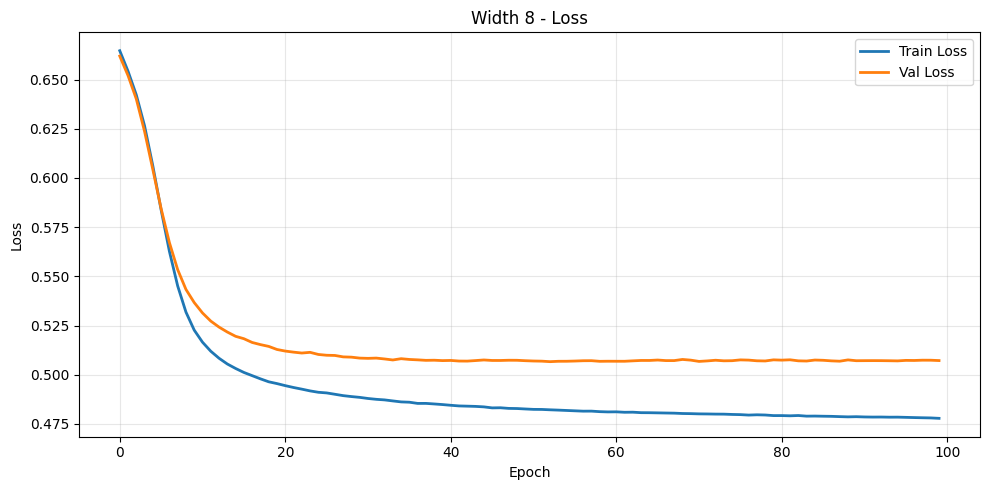

Width 8 Train Accuracy: 0.7629
Width 8 Val Accuracy: 0.7455

Width 16
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Va

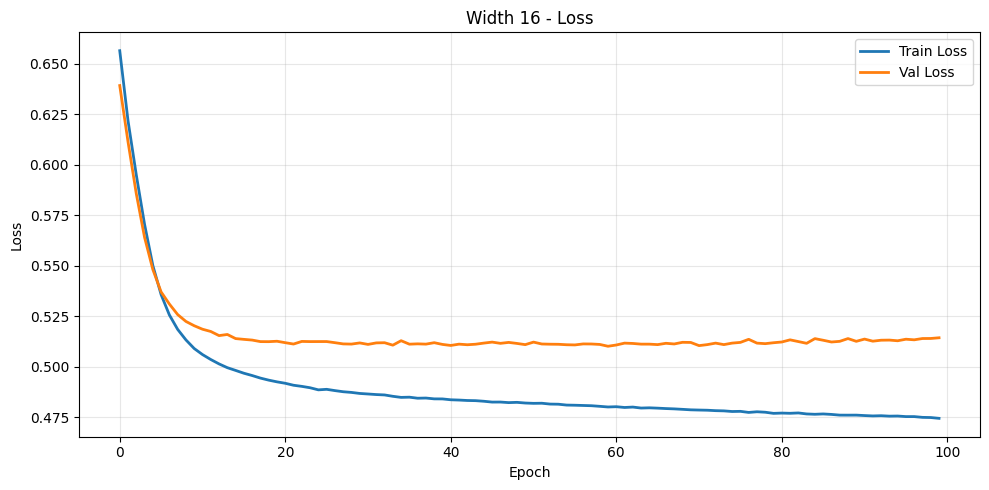

Width 16 Train Accuracy: 0.7630
Width 16 Val Accuracy: 0.7455

Width 32
Epoch 1/100 | Train Loss: 0.6533 | Val Loss: 0.5989
Epoch 2/100 | Train Loss: 0.5722 | Val Loss: 0.5632
Epoch 3/100 | Train Loss: 0.5424 | Val Loss: 0.5474
Epoch 4/100 | Train Loss: 0.5292 | Val Loss: 0.5382
Epoch 5/100 | Train Loss: 0.5197 | Val Loss: 0.5344
Epoch 6/100 | Train Loss: 0.5135 | Val Loss: 0.5291
Epoch 7/100 | Train Loss: 0.5087 | Val Loss: 0.5260
Epoch 8/100 | Train Loss: 0.5040 | Val Loss: 0.5246
Epoch 9/100 | Train Loss: 0.5009 | Val Loss: 0.5234
Epoch 10/100 | Train Loss: 0.4977 | Val Loss: 0.5230
Epoch 11/100 | Train Loss: 0.4957 | Val Loss: 0.5206
Epoch 12/100 | Train Loss: 0.4935 | Val Loss: 0.5189
Epoch 13/100 | Train Loss: 0.4917 | Val Loss: 0.5196
Epoch 14/100 | Train Loss: 0.4897 | Val Loss: 0.5214
Epoch 15/100 | Train Loss: 0.4882 | Val Loss: 0.5183
Epoch 16/100 | Train Loss: 0.4870 | Val Loss: 0.5173
Epoch 17/100 | Train Loss: 0.4851 | Val Loss: 0.5177
Epoch 18/100 | Train Loss: 0.4836 | 

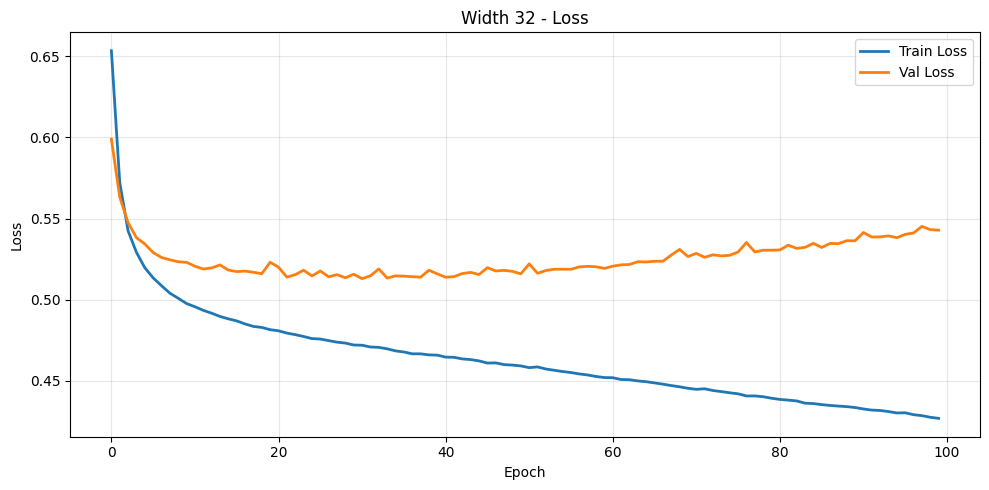

Width 32 Train Accuracy: 0.8034
Width 32 Val Accuracy: 0.7285


In [7]:
# 3 variasi width, depth tetap
EPOCHS = 100
LR = 0.01
BATCH_SIZE = 32
width_configs = {'Width 8':  [n_features, 8, 8, 8, 1], 'Width 16': [n_features, 16, 16, 16, 1], 'Width 32': [n_features, 32, 32, 32, 1],}
width_results = {}
for name, sizes in width_configs.items():
    print(f'\n{name}')
    activations = ['relu'] * (len(sizes) - 2) + ['sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=name)
    width_results[name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}

#### Perbandingan Loss per Epoch (Width)

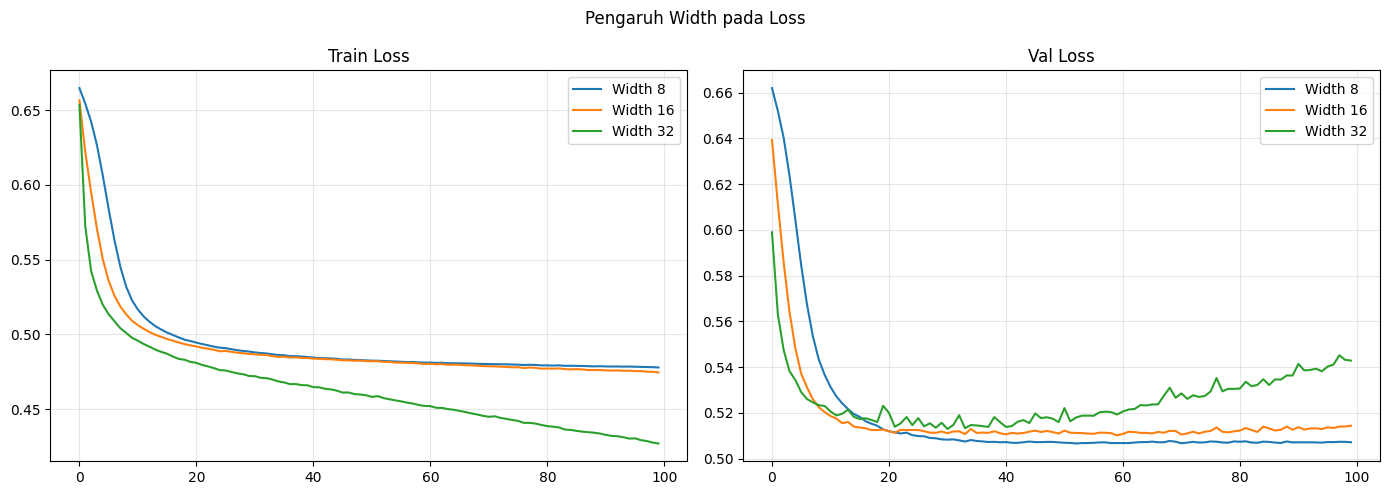


Rangkuman Akurasi
Width 8: Train=0.7629, Val=0.7455
Width 16: Train=0.7630, Val=0.7455
Width 32: Train=0.8034, Val=0.7285


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in width_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Width pada Loss')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi')
for name, res in width_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

### 4.2 Variasi Depth (Width Tetap = 16)


Depth 1
Epoch 1/100 | Train Loss: 0.6540 | Val Loss: 0.6114
Epoch 2/100 | Train Loss: 0.5910 | Val Loss: 0.5750
Epoch 3/100 | Train Loss: 0.5624 | Val Loss: 0.5545
Epoch 4/100 | Train Loss: 0.5444 | Val Loss: 0.5409
Epoch 5/100 | Train Loss: 0.5314 | Val Loss: 0.5313
Epoch 6/100 | Train Loss: 0.5221 | Val Loss: 0.5248
Epoch 7/100 | Train Loss: 0.5152 | Val Loss: 0.5206
Epoch 8/100 | Train Loss: 0.5103 | Val Loss: 0.5174
Epoch 9/100 | Train Loss: 0.5066 | Val Loss: 0.5153
Epoch 10/100 | Train Loss: 0.5037 | Val Loss: 0.5138
Epoch 11/100 | Train Loss: 0.5015 | Val Loss: 0.5129
Epoch 12/100 | Train Loss: 0.4998 | Val Loss: 0.5121
Epoch 13/100 | Train Loss: 0.4983 | Val Loss: 0.5114
Epoch 14/100 | Train Loss: 0.4969 | Val Loss: 0.5110
Epoch 15/100 | Train Loss: 0.4959 | Val Loss: 0.5104
Epoch 16/100 | Train Loss: 0.4949 | Val Loss: 0.5102
Epoch 17/100 | Train Loss: 0.4941 | Val Loss: 0.5100
Epoch 18/100 | Train Loss: 0.4933 | Val Loss: 0.5097
Epoch 19/100 | Train Loss: 0.4925 | Val Loss: 

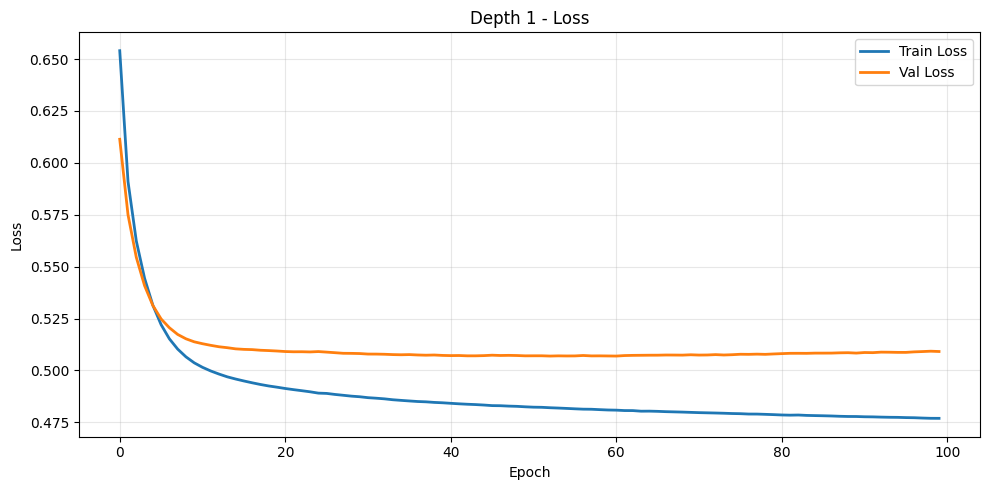

Depth 1 Train Accuracy: 0.7666
Depth 1 Val Accuracy: 0.7515

Depth 3
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val

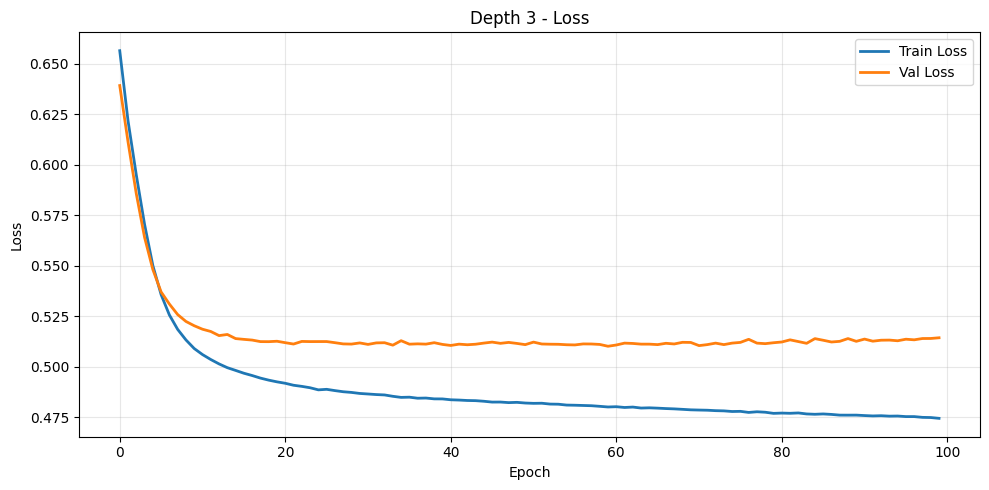

Depth 3 Train Accuracy: 0.7630
Depth 3 Val Accuracy: 0.7455

Depth 5
Epoch 1/100 | Train Loss: 0.6704 | Val Loss: 0.6550
Epoch 2/100 | Train Loss: 0.6421 | Val Loss: 0.6322
Epoch 3/100 | Train Loss: 0.6136 | Val Loss: 0.6021
Epoch 4/100 | Train Loss: 0.5825 | Val Loss: 0.5721
Epoch 5/100 | Train Loss: 0.5557 | Val Loss: 0.5522
Epoch 6/100 | Train Loss: 0.5382 | Val Loss: 0.5399
Epoch 7/100 | Train Loss: 0.5266 | Val Loss: 0.5326
Epoch 8/100 | Train Loss: 0.5185 | Val Loss: 0.5277
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5239
Epoch 10/100 | Train Loss: 0.5089 | Val Loss: 0.5218
Epoch 11/100 | Train Loss: 0.5058 | Val Loss: 0.5193
Epoch 12/100 | Train Loss: 0.5032 | Val Loss: 0.5179
Epoch 13/100 | Train Loss: 0.5010 | Val Loss: 0.5160
Epoch 14/100 | Train Loss: 0.4990 | Val Loss: 0.5169
Epoch 15/100 | Train Loss: 0.4975 | Val Loss: 0.5148
Epoch 16/100 | Train Loss: 0.4961 | Val Loss: 0.5142
Epoch 17/100 | Train Loss: 0.4948 | Val Loss: 0.5139
Epoch 18/100 | Train Loss: 0.4934 | Val

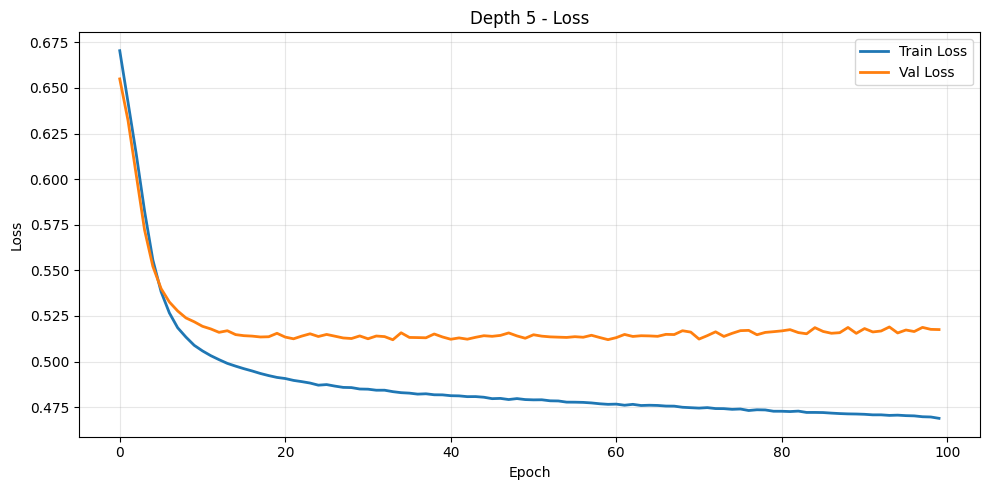

Depth 5 Train Accuracy: 0.7695
Depth 5 Val Accuracy: 0.7450


In [9]:
# 3 variasi depth, width tetap
depth_configs = {'Depth 1': [n_features, 16, 1], 'Depth 3': [n_features, 16, 16, 16, 1], 'Depth 5': [n_features, 16, 16, 16, 16, 16, 1],}

depth_results = {}
for name, sizes in depth_configs.items():
    print(f'\n{name}')
    activations = ['relu'] * (len(sizes) - 2) + ['sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=name)
    depth_results[name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}

#### Perbandingan Loss per Epoch (Depth)

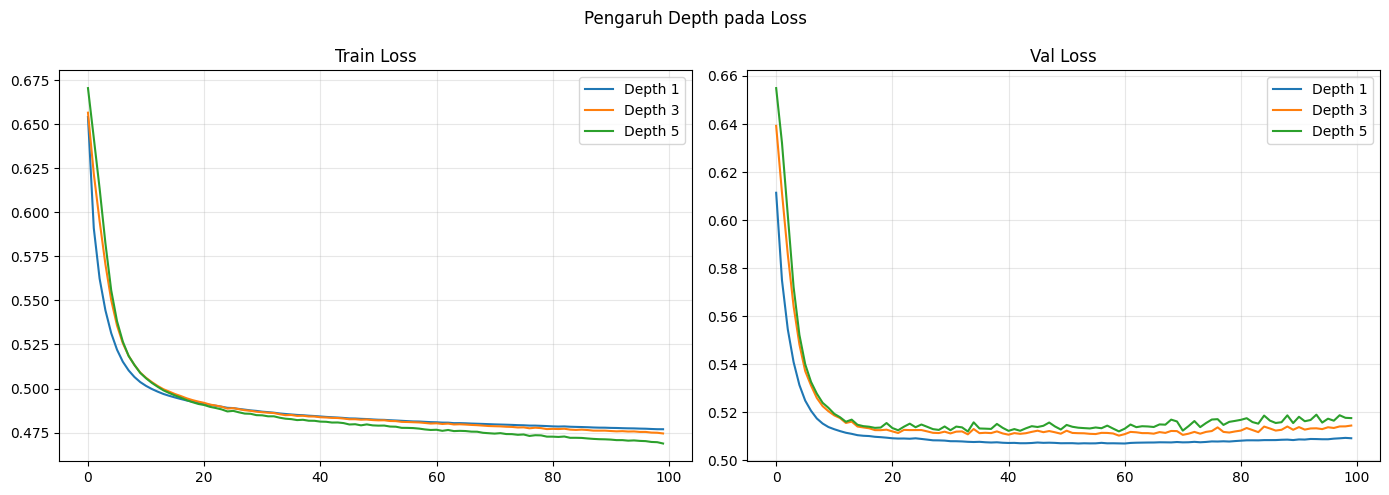


Rangkuman Akurasi
Depth 1: Train=0.7666, Val=0.7515
Depth 3: Train=0.7630, Val=0.7455
Depth 5: Train=0.7695, Val=0.7450


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in depth_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Depth pada Loss')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi')
for name, res in depth_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

## 5. Eksperimen 2: Pengaruh Fungsi Aktivasi Hidden Layer

Base arsitektur: 3 hidden layers [n_features, 16, 16, 16, 1]. Variasi aktivasi pada layer ke-2 (index 1).


Activation: linear
Epoch 1/100 | Train Loss: 0.6542 | Val Loss: 0.6068
Epoch 2/100 | Train Loss: 0.5864 | Val Loss: 0.5733
Epoch 3/100 | Train Loss: 0.5576 | Val Loss: 0.5508
Epoch 4/100 | Train Loss: 0.5384 | Val Loss: 0.5372
Epoch 5/100 | Train Loss: 0.5252 | Val Loss: 0.5296
Epoch 6/100 | Train Loss: 0.5173 | Val Loss: 0.5243
Epoch 7/100 | Train Loss: 0.5118 | Val Loss: 0.5220
Epoch 8/100 | Train Loss: 0.5075 | Val Loss: 0.5191
Epoch 9/100 | Train Loss: 0.5046 | Val Loss: 0.5170
Epoch 10/100 | Train Loss: 0.5017 | Val Loss: 0.5158
Epoch 11/100 | Train Loss: 0.4996 | Val Loss: 0.5147
Epoch 12/100 | Train Loss: 0.4978 | Val Loss: 0.5133
Epoch 13/100 | Train Loss: 0.4962 | Val Loss: 0.5120
Epoch 14/100 | Train Loss: 0.4948 | Val Loss: 0.5122
Epoch 15/100 | Train Loss: 0.4939 | Val Loss: 0.5102
Epoch 16/100 | Train Loss: 0.4929 | Val Loss: 0.5096
Epoch 17/100 | Train Loss: 0.4921 | Val Loss: 0.5092
Epoch 18/100 | Train Loss: 0.4911 | Val Loss: 0.5089
Epoch 19/100 | Train Loss: 0.4904 |

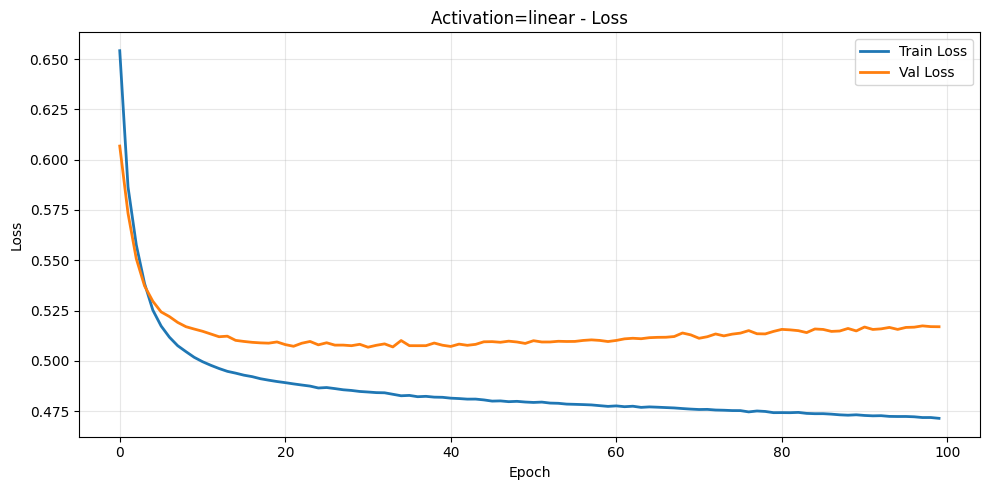

Activation=linear Train Accuracy: 0.7722
Activation=linear Val Accuracy: 0.7425

Activation: relu
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/1

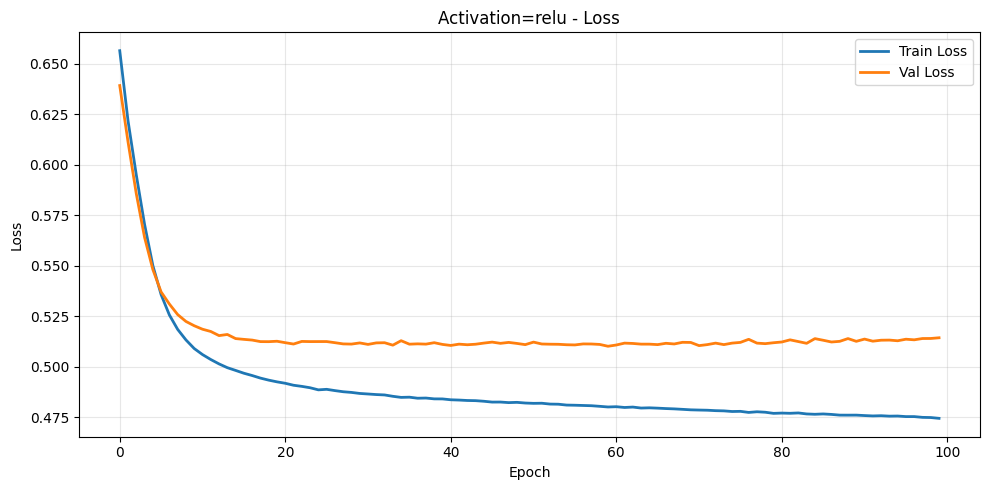

Activation=relu Train Accuracy: 0.7630
Activation=relu Val Accuracy: 0.7455

Activation: sigmoid
Epoch 1/100 | Train Loss: 0.6648 | Val Loss: 0.6600
Epoch 2/100 | Train Loss: 0.6492 | Val Loss: 0.6512
Epoch 3/100 | Train Loss: 0.6393 | Val Loss: 0.6416
Epoch 4/100 | Train Loss: 0.6287 | Val Loss: 0.6308
Epoch 5/100 | Train Loss: 0.6160 | Val Loss: 0.6180
Epoch 6/100 | Train Loss: 0.6014 | Val Loss: 0.6037
Epoch 7/100 | Train Loss: 0.5853 | Val Loss: 0.5887
Epoch 8/100 | Train Loss: 0.5689 | Val Loss: 0.5736
Epoch 9/100 | Train Loss: 0.5534 | Val Loss: 0.5602
Epoch 10/100 | Train Loss: 0.5398 | Val Loss: 0.5491
Epoch 11/100 | Train Loss: 0.5289 | Val Loss: 0.5403
Epoch 12/100 | Train Loss: 0.5207 | Val Loss: 0.5339
Epoch 13/100 | Train Loss: 0.5146 | Val Loss: 0.5289
Epoch 14/100 | Train Loss: 0.5100 | Val Loss: 0.5262
Epoch 15/100 | Train Loss: 0.5069 | Val Loss: 0.5227
Epoch 16/100 | Train Loss: 0.5043 | Val Loss: 0.5205
Epoch 17/100 | Train Loss: 0.5024 | Val Loss: 0.5194
Epoch 18/10

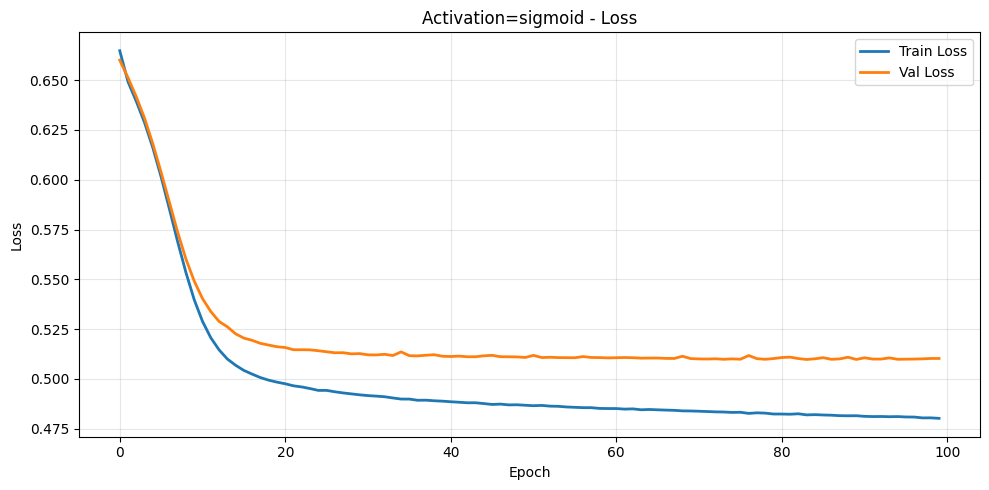

Activation=sigmoid Train Accuracy: 0.7640
Activation=sigmoid Val Accuracy: 0.7485

Activation: tanh
Epoch 1/100 | Train Loss: 0.6628 | Val Loss: 0.6412
Epoch 2/100 | Train Loss: 0.6160 | Val Loss: 0.6100
Epoch 3/100 | Train Loss: 0.5876 | Val Loss: 0.5844
Epoch 4/100 | Train Loss: 0.5631 | Val Loss: 0.5636
Epoch 5/100 | Train Loss: 0.5437 | Val Loss: 0.5490
Epoch 6/100 | Train Loss: 0.5307 | Val Loss: 0.5392
Epoch 7/100 | Train Loss: 0.5221 | Val Loss: 0.5342
Epoch 8/100 | Train Loss: 0.5166 | Val Loss: 0.5289
Epoch 9/100 | Train Loss: 0.5124 | Val Loss: 0.5259
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5239
Epoch 11/100 | Train Loss: 0.5067 | Val Loss: 0.5220
Epoch 12/100 | Train Loss: 0.5046 | Val Loss: 0.5210
Epoch 13/100 | Train Loss: 0.5028 | Val Loss: 0.5191
Epoch 14/100 | Train Loss: 0.5011 | Val Loss: 0.5186
Epoch 15/100 | Train Loss: 0.4998 | Val Loss: 0.5169
Epoch 16/100 | Train Loss: 0.4985 | Val Loss: 0.5161
Epoch 17/100 | Train Loss: 0.4975 | Val Loss: 0.5155
Epoch 18

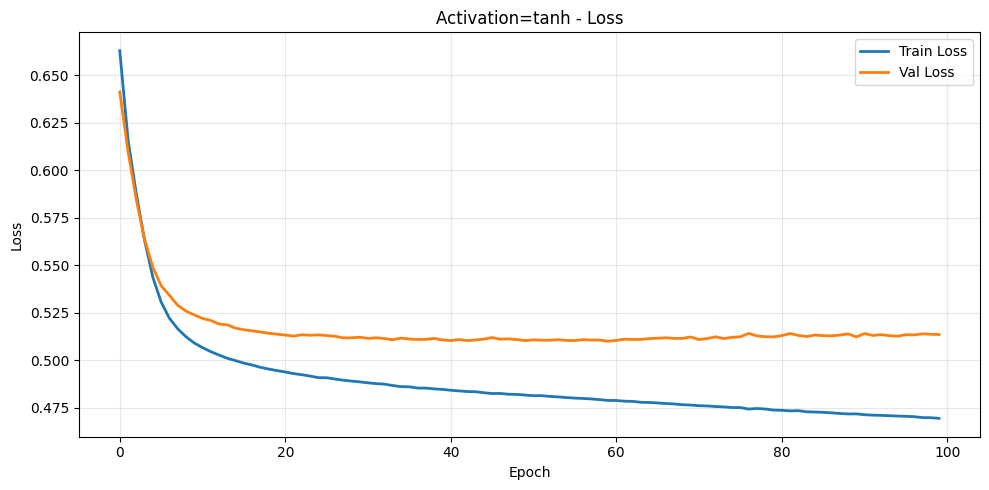

Activation=tanh Train Accuracy: 0.7691
Activation=tanh Val Accuracy: 0.7390


In [11]:
activation_names = ['linear', 'relu', 'sigmoid', 'tanh']
activation_results = {}

for act_name in activation_names:
    print(f'\nActivation: {act_name}')
    activations = ['relu', act_name, 'relu', 'sigmoid']
    sizes = [n_features, 16, 16, 16, 1]
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=f'Activation={act_name}')
    activation_results[act_name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc}

#### Perbandingan Loss per Epoch (Aktivasi)

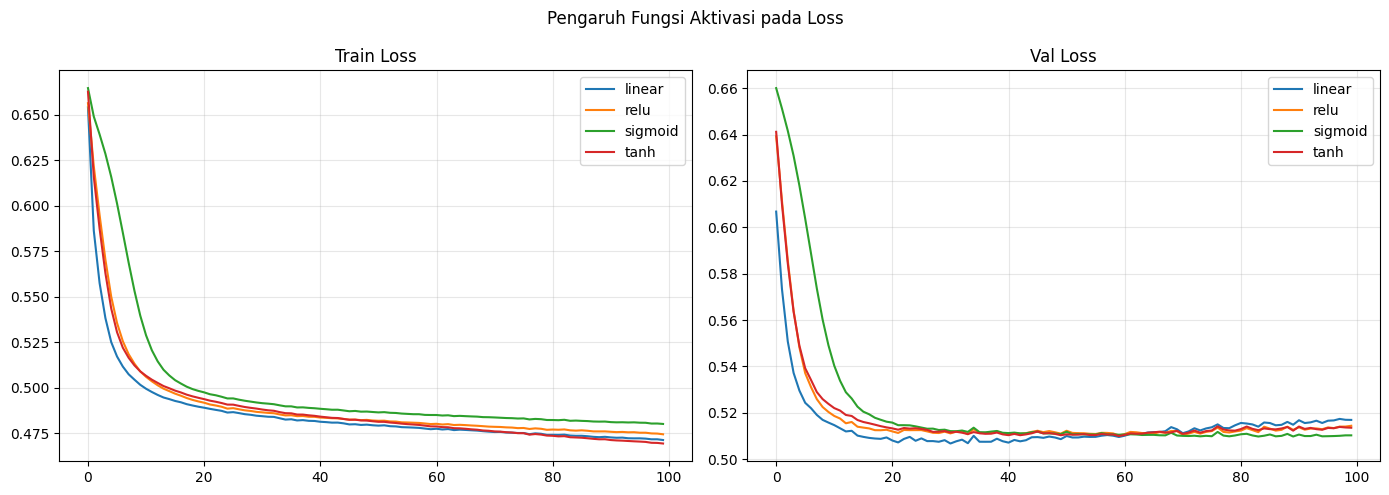


Rangkuman Akurasi
linear: Train=0.7722, Val=0.7425
relu: Train=0.7630, Val=0.7455
sigmoid: Train=0.7640, Val=0.7485
tanh: Train=0.7691, Val=0.7390


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in activation_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Fungsi Aktivasi pada Loss')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi')
for name, res in activation_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

## 6. Eksperimen 3: Pengaruh Learning Rate

Epoch 1/100 | Train Loss: 0.6905 | Val Loss: 0.6865
Epoch 2/100 | Train Loss: 0.6726 | Val Loss: 0.6757
Epoch 3/100 | Train Loss: 0.6647 | Val Loss: 0.6686
Epoch 4/100 | Train Loss: 0.6589 | Val Loss: 0.6628
Epoch 5/100 | Train Loss: 0.6541 | Val Loss: 0.6578
Epoch 6/100 | Train Loss: 0.6498 | Val Loss: 0.6534
Epoch 7/100 | Train Loss: 0.6459 | Val Loss: 0.6494
Epoch 8/100 | Train Loss: 0.6424 | Val Loss: 0.6458
Epoch 9/100 | Train Loss: 0.6392 | Val Loss: 0.6424
Epoch 10/100 | Train Loss: 0.6361 | Val Loss: 0.6392
Epoch 11/100 | Train Loss: 0.6331 | Val Loss: 0.6361
Epoch 12/100 | Train Loss: 0.6302 | Val Loss: 0.6331
Epoch 13/100 | Train Loss: 0.6274 | Val Loss: 0.6303
Epoch 14/100 | Train Loss: 0.6246 | Val Loss: 0.6274
Epoch 15/100 | Train Loss: 0.6218 | Val Loss: 0.6245
Epoch 16/100 | Train Loss: 0.6191 | Val Loss: 0.6218
Epoch 17/100 | Train Loss: 0.6164 | Val Loss: 0.6190
Epoch 18/100 | Train Loss: 0.6137 | Val Loss: 0.6163
Epoch 19/100 | Train Loss: 0.6110 | Val Loss: 0.6135
Ep

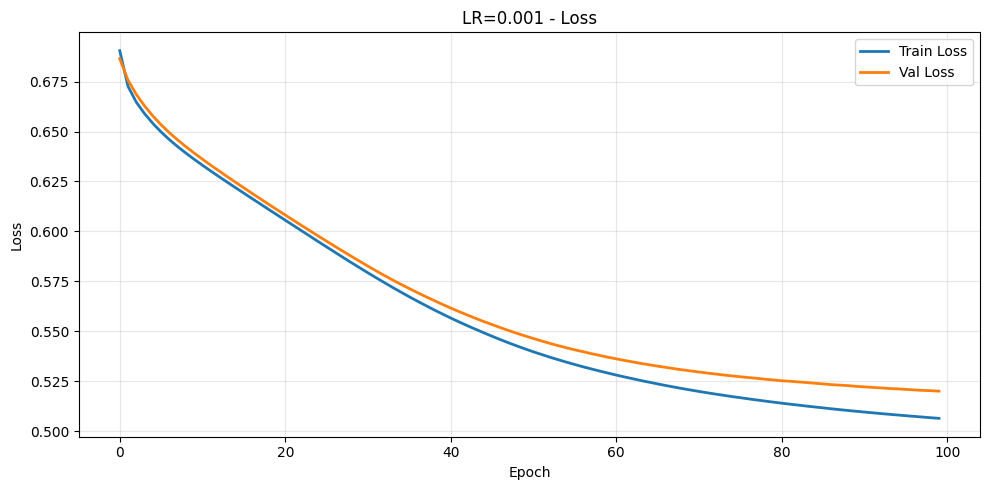

LR=0.001 Train Accuracy: 0.7506
LR=0.001 Val Accuracy: 0.7370
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val Loss: 

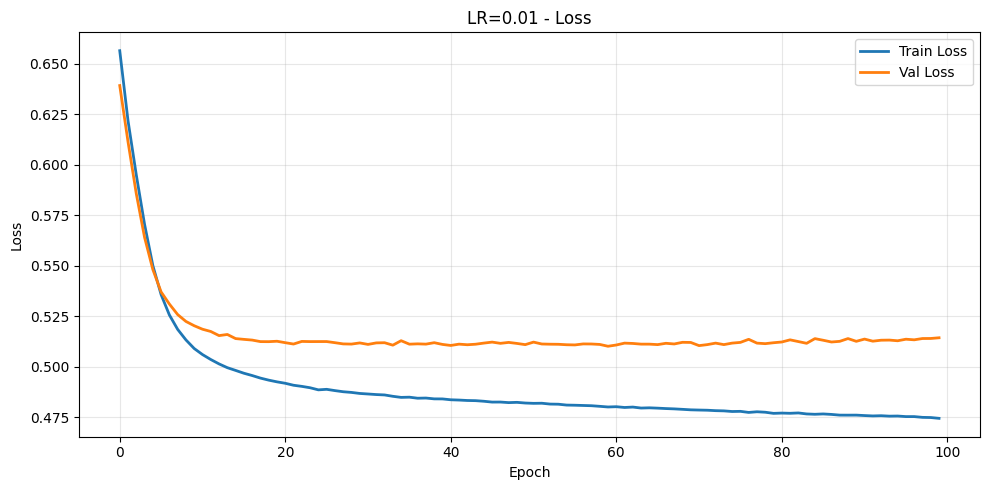

LR=0.01 Train Accuracy: 0.7630
LR=0.01 Val Accuracy: 0.7455
Epoch 1/100 | Train Loss: 0.5691 | Val Loss: 0.5247
Epoch 2/100 | Train Loss: 0.5078 | Val Loss: 0.5139
Epoch 3/100 | Train Loss: 0.4956 | Val Loss: 0.5113
Epoch 4/100 | Train Loss: 0.4928 | Val Loss: 0.5096
Epoch 5/100 | Train Loss: 0.4883 | Val Loss: 0.5116
Epoch 6/100 | Train Loss: 0.4880 | Val Loss: 0.5110
Epoch 7/100 | Train Loss: 0.4866 | Val Loss: 0.5103
Epoch 8/100 | Train Loss: 0.4840 | Val Loss: 0.5110
Epoch 9/100 | Train Loss: 0.4832 | Val Loss: 0.5110
Epoch 10/100 | Train Loss: 0.4811 | Val Loss: 0.5185
Epoch 11/100 | Train Loss: 0.4805 | Val Loss: 0.5147
Epoch 12/100 | Train Loss: 0.4803 | Val Loss: 0.5128
Epoch 13/100 | Train Loss: 0.4792 | Val Loss: 0.5146
Epoch 14/100 | Train Loss: 0.4782 | Val Loss: 0.5190
Epoch 15/100 | Train Loss: 0.4772 | Val Loss: 0.5141
Epoch 16/100 | Train Loss: 0.4770 | Val Loss: 0.5147
Epoch 17/100 | Train Loss: 0.4756 | Val Loss: 0.5145
Epoch 18/100 | Train Loss: 0.4739 | Val Loss: 0.

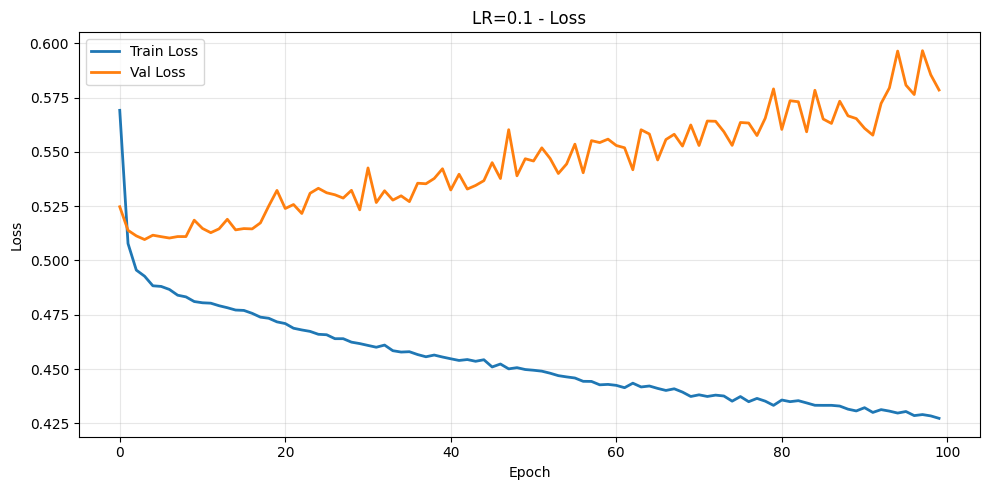

LR=0.1 Train Accuracy: 0.7999
LR=0.1 Val Accuracy: 0.7315


In [13]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates:
    sizes = [n_features, 16, 16, 16, 1]
    activations = ['relu', 'relu', 'relu', 'sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=lr, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=f'LR={lr}')
    lr_results[lr] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}

#### Perbandingan Loss per Epoch (Learning Rate)

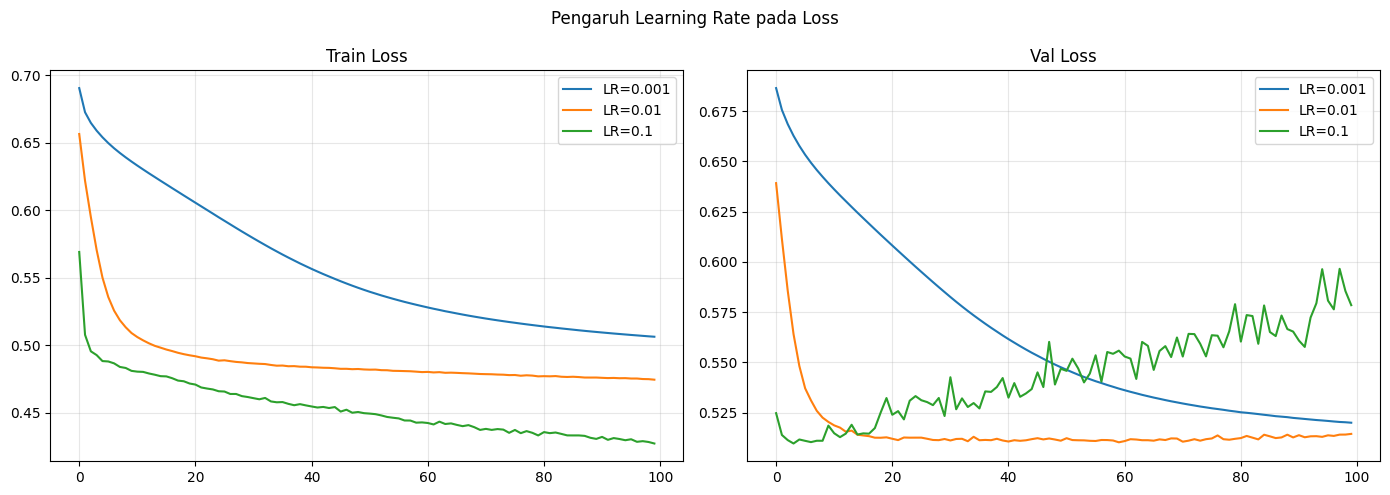


Rangkuman Akurasi
LR=0.001: Train=0.7506, Val=0.7370
LR=0.01: Train=0.7630, Val=0.7455
LR=0.1: Train=0.7999, Val=0.7315


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, res in lr_results.items():
    axes[0].plot(res['history']['train_loss'], label=f'LR={lr}')
    axes[1].plot(res['history']['val_loss'], label=f'LR={lr}')
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Learning Rate pada Loss')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi')
for lr, res in lr_results.items():
    print(f'LR={lr}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

#### Distribusi Bobot & Gradien (Learning Rate)


LR=0.001


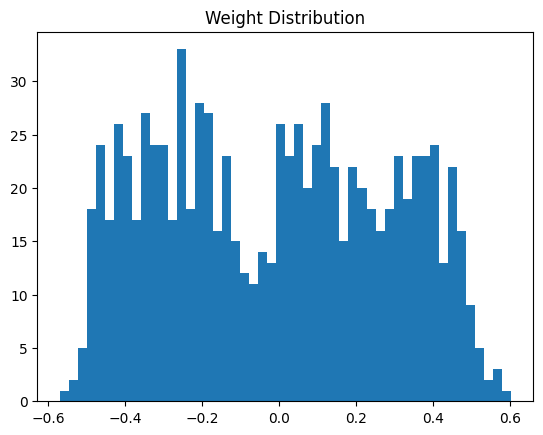

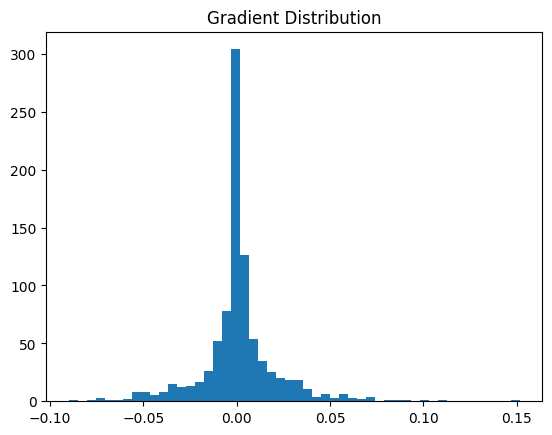


LR=0.01


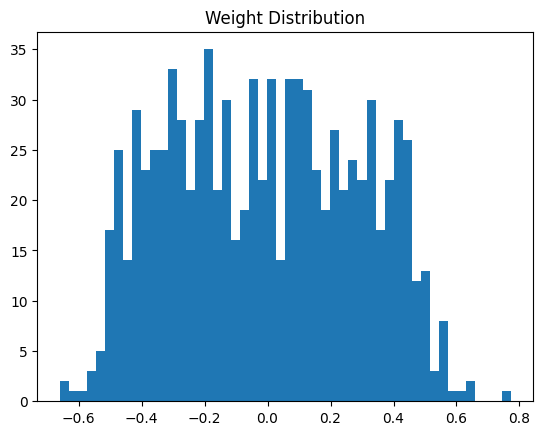

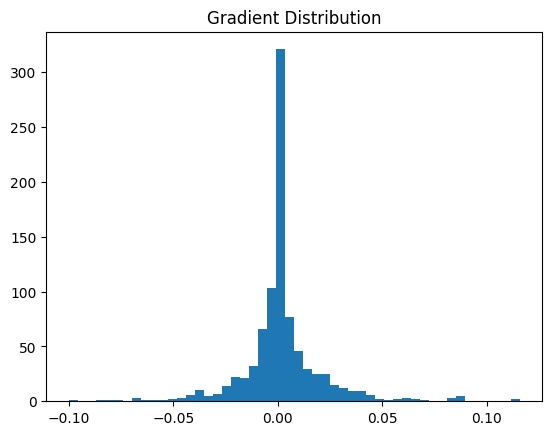


LR=0.1


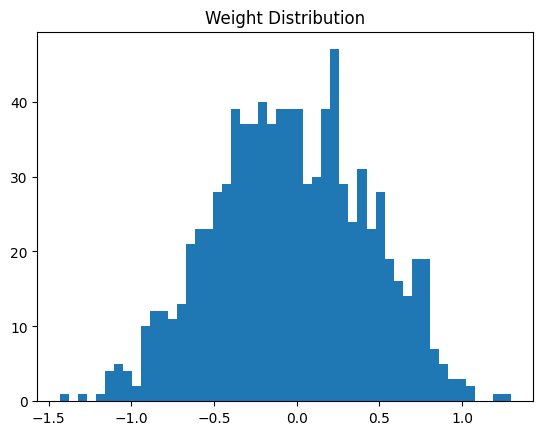

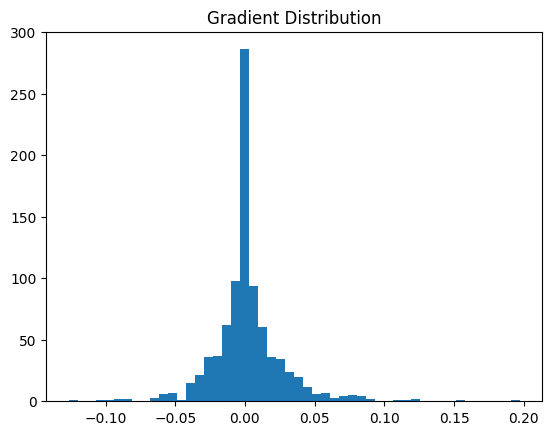

In [15]:
for lr, res in lr_results.items():
    print(f'\nLR={lr}')
    model = res['model']
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

## 7. Eksperimen 4: Pengaruh Regularisasi


No Reg
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val Loss: 0.5125
Epoch 19/100 | Train Loss: 0.4935 | Val Loss: 0

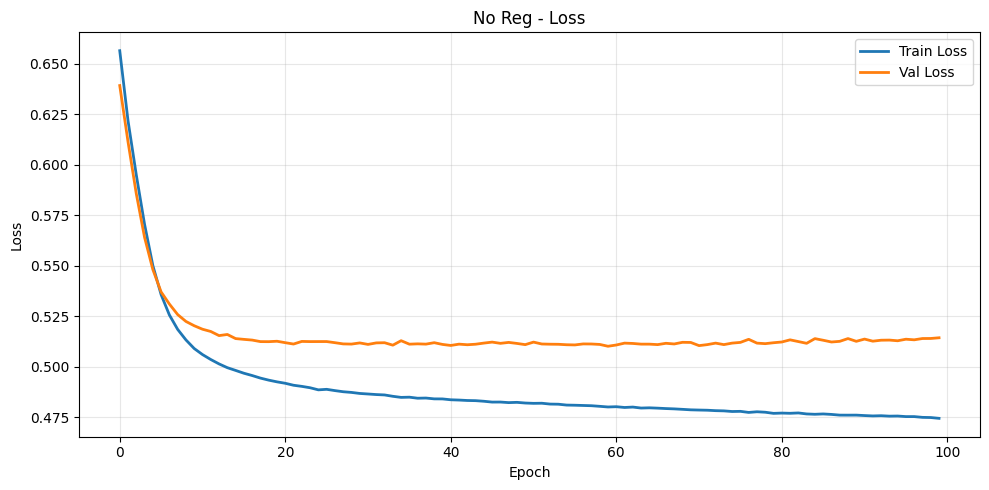

No Reg Train Accuracy: 0.7630
No Reg Val Accuracy: 0.7455

L1 (lambda=0.001)
Epoch 1/100 | Train Loss: 0.6562 | Val Loss: 0.6391
Epoch 2/100 | Train Loss: 0.6220 | Val Loss: 0.6120
Epoch 3/100 | Train Loss: 0.5956 | Val Loss: 0.5867
Epoch 4/100 | Train Loss: 0.5711 | Val Loss: 0.5650
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5487
Epoch 6/100 | Train Loss: 0.5351 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5246 | Val Loss: 0.5308
Epoch 8/100 | Train Loss: 0.5173 | Val Loss: 0.5253
Epoch 9/100 | Train Loss: 0.5120 | Val Loss: 0.5217
Epoch 10/100 | Train Loss: 0.5079 | Val Loss: 0.5193
Epoch 11/100 | Train Loss: 0.5048 | Val Loss: 0.5176
Epoch 12/100 | Train Loss: 0.5024 | Val Loss: 0.5166
Epoch 13/100 | Train Loss: 0.5001 | Val Loss: 0.5146
Epoch 14/100 | Train Loss: 0.4982 | Val Loss: 0.5147
Epoch 15/100 | Train Loss: 0.4968 | Val Loss: 0.5129
Epoch 16/100 | Train Loss: 0.4954 | Val Loss: 0.5124
Epoch 17/100 | Train Loss: 0.4942 | Val Loss: 0.5121
Epoch 18/100 | Train Loss: 0.49

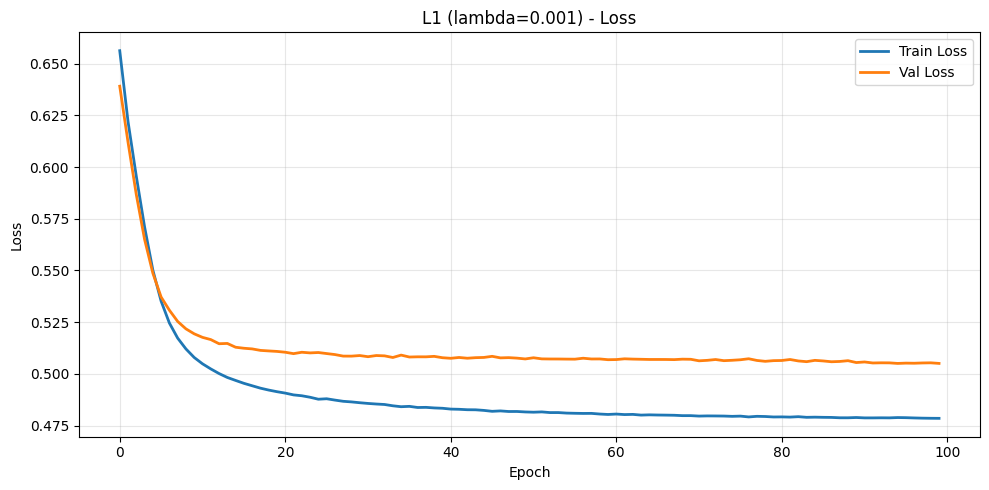

L1 (lambda=0.001) Train Accuracy: 0.7692
L1 (lambda=0.001) Val Accuracy: 0.7520

L2 (lambda=0.001)
Epoch 1/100 | Train Loss: 0.6564 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6220 | Val Loss: 0.6118
Epoch 3/100 | Train Loss: 0.5953 | Val Loss: 0.5862
Epoch 4/100 | Train Loss: 0.5708 | Val Loss: 0.5644
Epoch 5/100 | Train Loss: 0.5501 | Val Loss: 0.5481
Epoch 6/100 | Train Loss: 0.5352 | Val Loss: 0.5367
Epoch 7/100 | Train Loss: 0.5249 | Val Loss: 0.5305
Epoch 8/100 | Train Loss: 0.5176 | Val Loss: 0.5252
Epoch 9/100 | Train Loss: 0.5123 | Val Loss: 0.5217
Epoch 10/100 | Train Loss: 0.5081 | Val Loss: 0.5194
Epoch 11/100 | Train Loss: 0.5051 | Val Loss: 0.5178
Epoch 12/100 | Train Loss: 0.5027 | Val Loss: 0.5167
Epoch 13/100 | Train Loss: 0.5005 | Val Loss: 0.5149
Epoch 14/100 | Train Loss: 0.4986 | Val Loss: 0.5152
Epoch 15/100 | Train Loss: 0.4973 | Val Loss: 0.5134
Epoch 16/100 | Train Loss: 0.4959 | Val Loss: 0.5130
Epoch 17/100 | Train Loss: 0.4947 | Val Loss: 0.5128
Epoch 18/

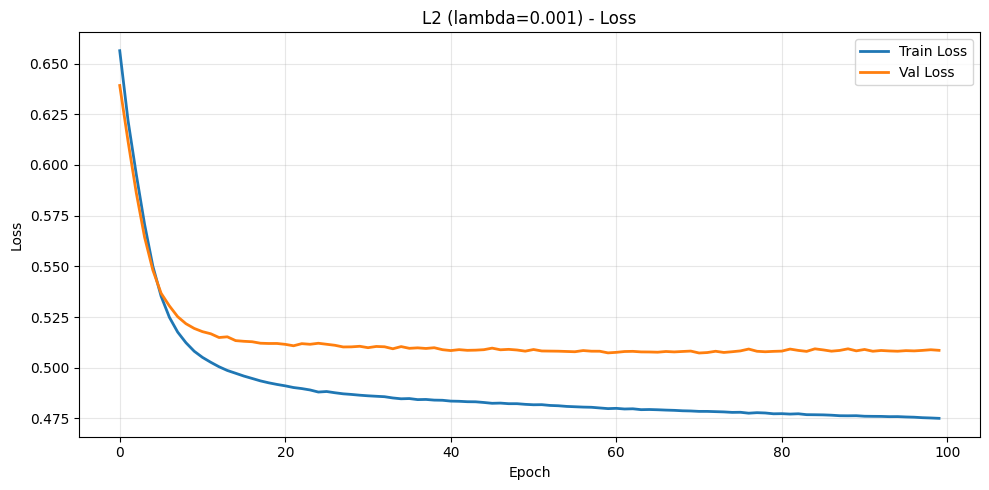

L2 (lambda=0.001) Train Accuracy: 0.7665
L2 (lambda=0.001) Val Accuracy: 0.7460


In [16]:
reg_configs = {'No Reg': {'reg_type': None, 'reg_lambda': 0.0}, 'L1 (lambda=0.001)': {'reg_type': 'l1', 'reg_lambda': 0.001}, 'L2 (lambda=0.001)': {'reg_type': 'l2', 'reg_lambda': 0.001},}

reg_results = {}
for name, config in reg_configs.items():
    print(f'\n{name}')
    sizes = [n_features, 16, 16, 16, 1]
    activations = ['relu', 'relu', 'relu', 'sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=name,
        reg_type=config['reg_type'], reg_lambda=config['reg_lambda'])
    reg_results[name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}

#### Perbandingan Loss per Epoch (Regularisasi)

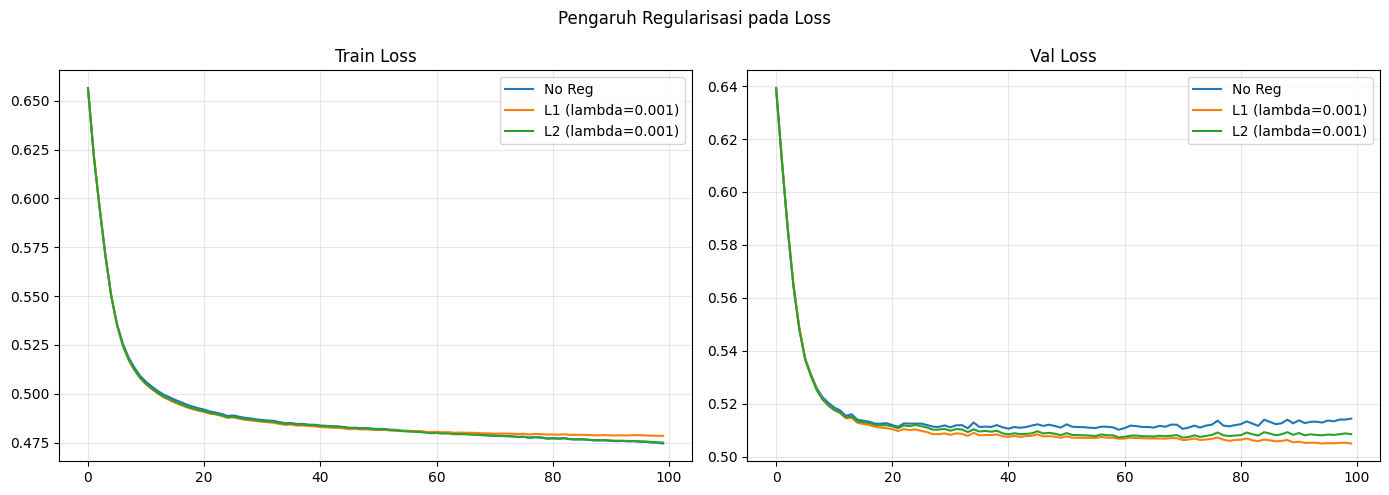

No Reg: Train=0.7630, Val=0.7455
L1 (lambda=0.001): Train=0.7692, Val=0.7520
L2 (lambda=0.001): Train=0.7665, Val=0.7460


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in reg_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Regularisasi pada Loss')
plt.tight_layout()
plt.show()

for name, res in reg_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

#### Distribusi Bobot & Gradien (Regularisasi)

No Reg


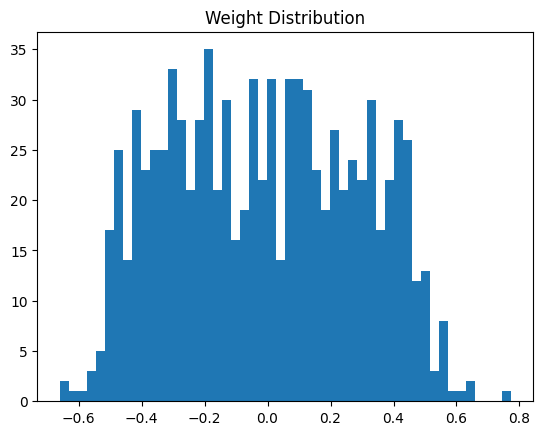

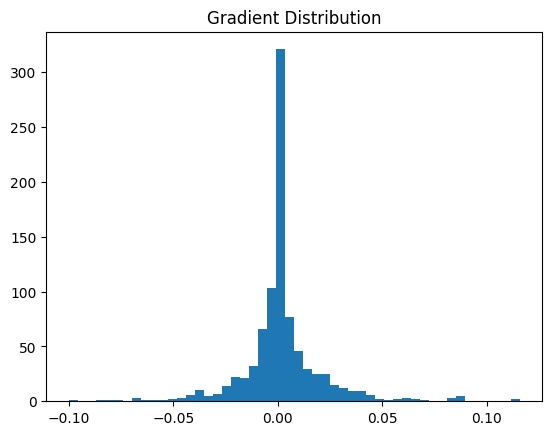

L1 (lambda=0.001)


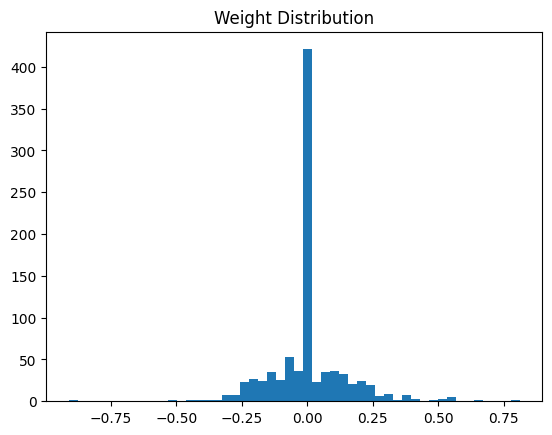

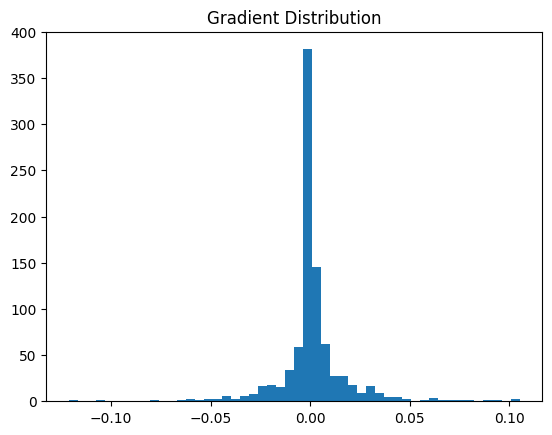

L2 (lambda=0.001)


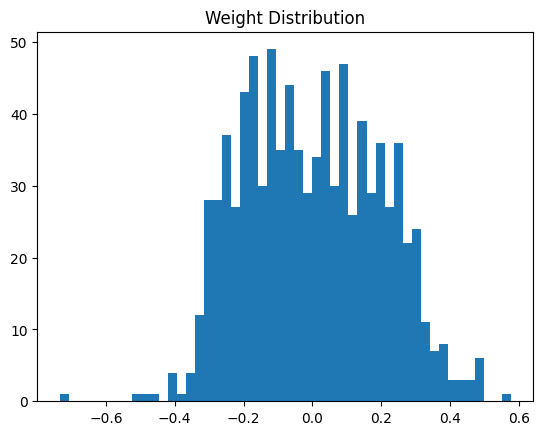

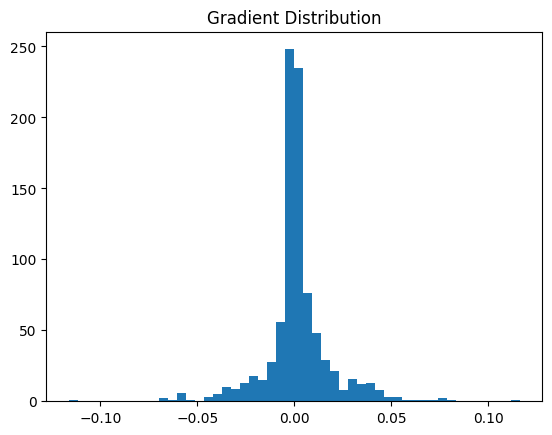

In [18]:
for name, res in reg_results.items():
    print(name)
    model = res['model']
    model.plot_weight_distribution()
    model.plot_gradient_distribution()

## 8. Eksperimen 5: Pengaruh Optimizer (Adam vs SGD)



Optimizer: SGD
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val Loss: 0.5125
Epoch 19/100 | Train Loss: 0.4935 | Val

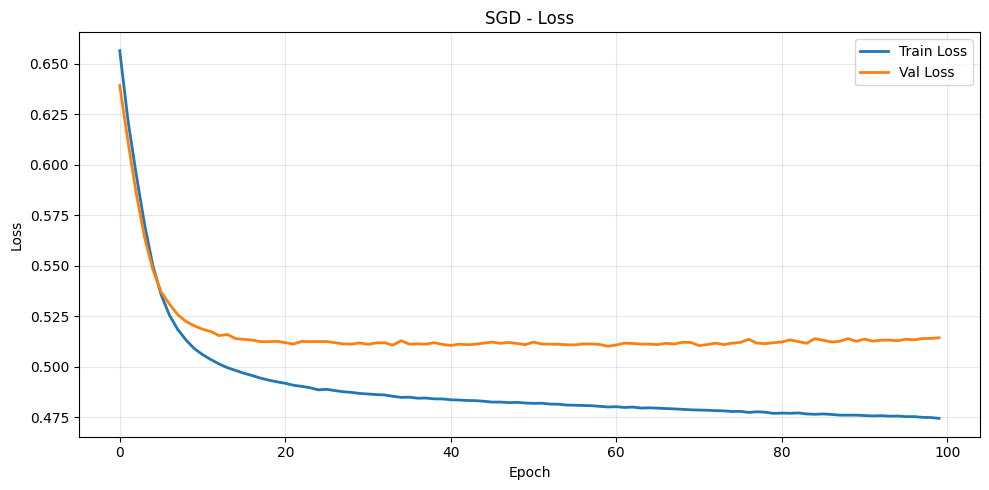

SGD Train Accuracy: 0.7630
SGD Val Accuracy: 0.7455

Optimizer: Adam
Epoch 1/100 | Train Loss: 0.5268 | Val Loss: 0.5157
Epoch 2/100 | Train Loss: 0.4956 | Val Loss: 0.5175
Epoch 3/100 | Train Loss: 0.4902 | Val Loss: 0.5122
Epoch 4/100 | Train Loss: 0.4887 | Val Loss: 0.5085
Epoch 5/100 | Train Loss: 0.4856 | Val Loss: 0.5135
Epoch 6/100 | Train Loss: 0.4826 | Val Loss: 0.5109
Epoch 7/100 | Train Loss: 0.4797 | Val Loss: 0.5121
Epoch 8/100 | Train Loss: 0.4788 | Val Loss: 0.5206
Epoch 9/100 | Train Loss: 0.4798 | Val Loss: 0.5167
Epoch 10/100 | Train Loss: 0.4773 | Val Loss: 0.5245
Epoch 11/100 | Train Loss: 0.4732 | Val Loss: 0.5162
Epoch 12/100 | Train Loss: 0.4731 | Val Loss: 0.5185
Epoch 13/100 | Train Loss: 0.4702 | Val Loss: 0.5171
Epoch 14/100 | Train Loss: 0.4684 | Val Loss: 0.5336
Epoch 15/100 | Train Loss: 0.4671 | Val Loss: 0.5334
Epoch 16/100 | Train Loss: 0.4647 | Val Loss: 0.5215
Epoch 17/100 | Train Loss: 0.4635 | Val Loss: 0.5281
Epoch 18/100 | Train Loss: 0.4607 | Val

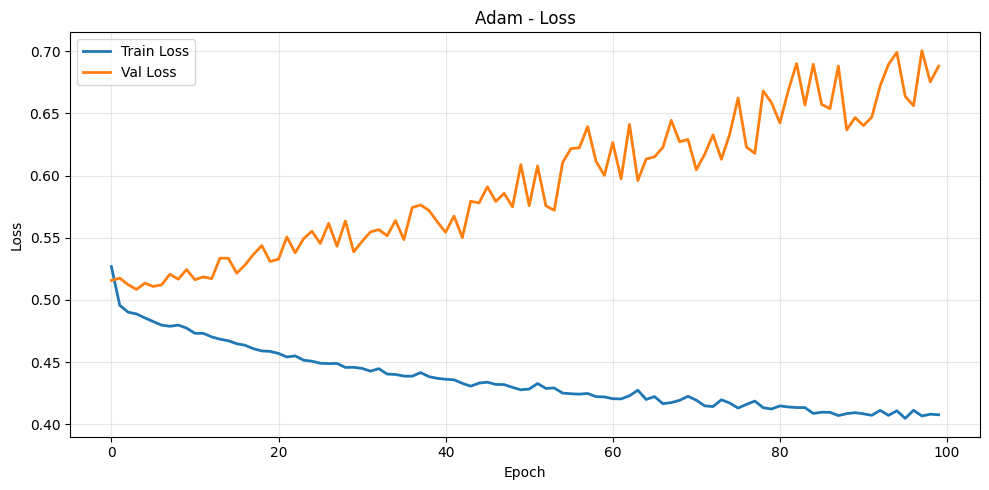

Adam Train Accuracy: 0.8174
Adam Val Accuracy: 0.7120


In [19]:
opt_configs = {'SGD': 'sgd','Adam': 'adam'}

opt_results = {}
for name, opt in opt_configs.items():
    print(f'\nOptimizer: {name}')
    sizes = [n_features, 16, 16, 16, 1]
    activations = ['relu', 'relu', 'relu', 'sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=name, optimizer=opt)
    opt_results[name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}


#### Perbandingan Loss per Epoch (Optimizer)


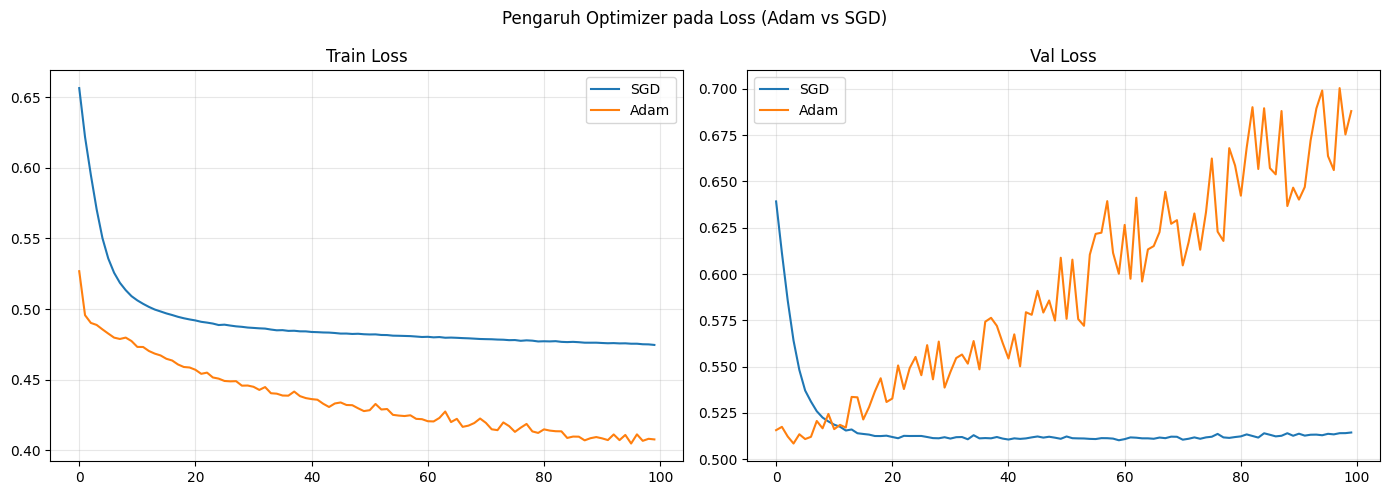


Rangkuman Akurasi
SGD: Train=0.7630, Val=0.7455
Adam: Train=0.8174, Val=0.7120


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in opt_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh Optimizer pada Loss (Adam vs SGD)')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi')
for name, res in opt_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')


## 9. Uji Perbandingan: FFNN vs sklearn MLPClassifier

In [21]:
from sklearn.neural_network import MLPClassifier

sizes = [n_features, 16, 16, 16, 1]
activations = ['relu', 'relu', 'relu', 'sigmoid']
our_model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42)
our_hist = our_model.fit(X_train_list, y_train_list, epochs=EPOCHS,
                         learning_rate=LR, batch_size=BATCH_SIZE,
                         loss_fn='bce', X_val=X_val_list, y_val=y_val_list, verbose=1)
our_train_acc, _ = evaluate_model(our_model, X_train_list, y_train.tolist(), 'Our FFNN Train')
our_val_acc, our_pred = evaluate_model(our_model, X_val_list, y_val.tolist(), 'Our FFNN Val')

sklearn_model = MLPClassifier(
    hidden_layer_sizes=(16, 16, 16),
    activation='relu',
    solver='sgd',
    learning_rate_init=LR,
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    random_state=42,
    verbose=False
)
sklearn_model.fit(X_train, y_train)
sklearn_train_acc = sklearn_model.score(X_train, y_train)
sklearn_val_acc = sklearn_model.score(X_val, y_val)
sklearn_pred = sklearn_model.predict(X_val)
print(f'sklearn Train Accuracy: {sklearn_train_acc:.4f}')
print(f'sklearn Val Accuracy: {sklearn_val_acc:.4f}')

Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val Loss: 0.5125
Epoch 19/100 | Train Loss: 0.4935 | Val Loss: 0.5125
Ep

c:\Users\Adam Mirza\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


### Perbandingan Hasil

In [22]:
print(f'Our FFNN: Train={our_train_acc:.4f}, Val={our_val_acc:.4f}')
print(f'sklearn MLP: Train={sklearn_train_acc:.4f}, Val={sklearn_val_acc:.4f}')

print('\nClassification Report (Our FFNN)')
print(classification_report(y_val, our_pred, target_names=['Not Placed', 'Placed']))

print('Classification Report (sklearn MLP)')
print(classification_report(y_val, sklearn_pred, target_names=['Not Placed', 'Placed']))

Our FFNN: Train=0.7630, Val=0.7455
sklearn MLP: Train=0.8184, Val=0.7105

Classification Report (Our FFNN)
              precision    recall  f1-score   support

  Not Placed       0.69      0.62      0.65       769
      Placed       0.78      0.82      0.80      1231

    accuracy                           0.75      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.74      0.75      0.74      2000

Classification Report (sklearn MLP)
              precision    recall  f1-score   support

  Not Placed       0.63      0.61      0.62       769
      Placed       0.76      0.77      0.77      1231

    accuracy                           0.71      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.71      0.71      0.71      2000



## 10. Eksperimen 6: Pengaruh RMSNorm (BONUS)



Tanpa RMSNorm
Epoch 1/100 | Train Loss: 0.6565 | Val Loss: 0.6392
Epoch 2/100 | Train Loss: 0.6218 | Val Loss: 0.6114
Epoch 3/100 | Train Loss: 0.5950 | Val Loss: 0.5857
Epoch 4/100 | Train Loss: 0.5705 | Val Loss: 0.5641
Epoch 5/100 | Train Loss: 0.5502 | Val Loss: 0.5482
Epoch 6/100 | Train Loss: 0.5358 | Val Loss: 0.5371
Epoch 7/100 | Train Loss: 0.5257 | Val Loss: 0.5311
Epoch 8/100 | Train Loss: 0.5186 | Val Loss: 0.5259
Epoch 9/100 | Train Loss: 0.5134 | Val Loss: 0.5225
Epoch 10/100 | Train Loss: 0.5091 | Val Loss: 0.5204
Epoch 11/100 | Train Loss: 0.5061 | Val Loss: 0.5187
Epoch 12/100 | Train Loss: 0.5037 | Val Loss: 0.5175
Epoch 13/100 | Train Loss: 0.5015 | Val Loss: 0.5155
Epoch 14/100 | Train Loss: 0.4996 | Val Loss: 0.5161
Epoch 15/100 | Train Loss: 0.4983 | Val Loss: 0.5140
Epoch 16/100 | Train Loss: 0.4969 | Val Loss: 0.5136
Epoch 17/100 | Train Loss: 0.4957 | Val Loss: 0.5133
Epoch 18/100 | Train Loss: 0.4945 | Val Loss: 0.5125
Epoch 19/100 | Train Loss: 0.4935 | Val 

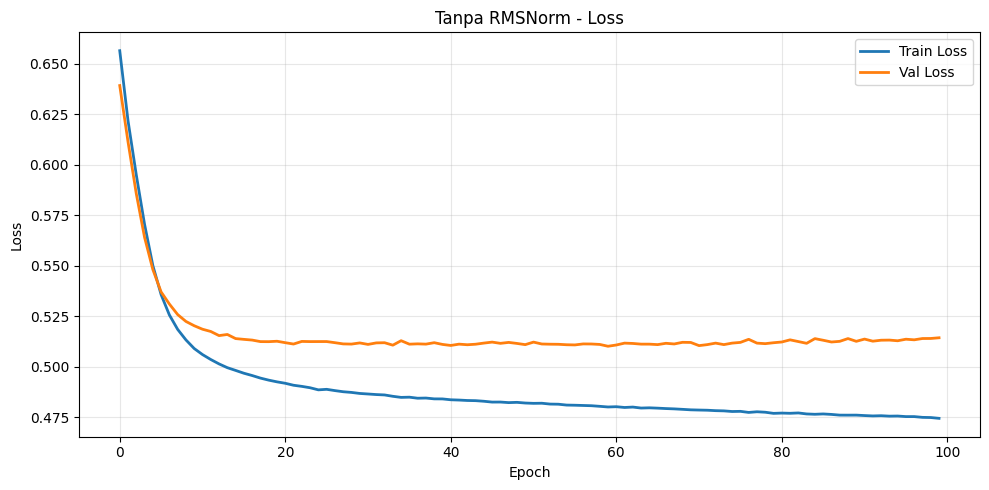

Tanpa RMSNorm Train Accuracy: 0.7630
Tanpa RMSNorm Val Accuracy: 0.7455

Dengan RMSNorm
Epoch 1/100 | Train Loss: 0.6544 | Val Loss: 0.6249
Epoch 2/100 | Train Loss: 0.6153 | Val Loss: 0.6268
Epoch 3/100 | Train Loss: 0.6450 | Val Loss: 0.6433
Epoch 4/100 | Train Loss: 0.6347 | Val Loss: 0.6264
Epoch 5/100 | Train Loss: 0.6218 | Val Loss: 0.6186
Epoch 6/100 | Train Loss: 0.6219 | Val Loss: 0.6278
Epoch 7/100 | Train Loss: 0.6299 | Val Loss: 0.6336
Epoch 8/100 | Train Loss: 0.6239 | Val Loss: 0.6077
Epoch 9/100 | Train Loss: 0.5919 | Val Loss: 0.5705
Epoch 10/100 | Train Loss: 0.5438 | Val Loss: 0.5451
Epoch 11/100 | Train Loss: 0.5334 | Val Loss: 0.5389
Epoch 12/100 | Train Loss: 0.5371 | Val Loss: 0.5557
Epoch 13/100 | Train Loss: 0.5439 | Val Loss: 0.5579
Epoch 14/100 | Train Loss: 0.5461 | Val Loss: 0.5645
Epoch 15/100 | Train Loss: 0.5484 | Val Loss: 0.5611
Epoch 16/100 | Train Loss: 0.5500 | Val Loss: 0.5598
Epoch 17/100 | Train Loss: 0.5547 | Val Loss: 0.5674
Epoch 18/100 | Train

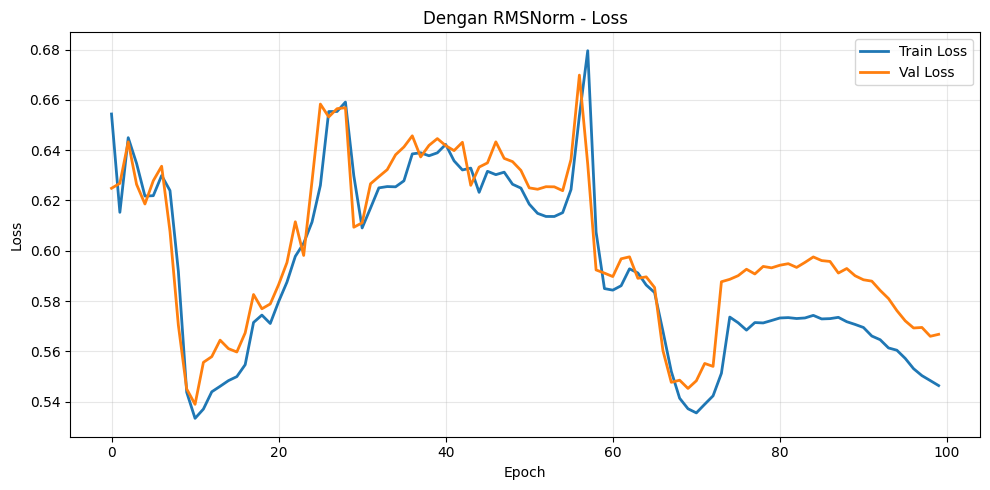

Dengan RMSNorm Train Accuracy: 0.7218
Dengan RMSNorm Val Accuracy: 0.7070


In [23]:
norm_configs = {
    'Tanpa RMSNorm': False,
    'Dengan RMSNorm': True
}

norm_results = {}
for name, use_rmsnorm in norm_configs.items():
    print(f'\n{name}')
    sizes = [n_features, 16, 16, 16, 1]
    activations = ['relu', 'relu', 'relu', 'sigmoid']
    model = FFNN(sizes, activations, init_method='uniform',
                 init_params={'low': -0.5, 'high': 0.5}, seed=42, use_rmsnorm=use_rmsnorm)
    hist, train_acc, val_acc = train_and_evaluate(
        model, X_train_list, y_train_list, X_val_list, y_val_list,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE, loss_fn='bce',
        verbose=1, title=name)
    norm_results[name] = {'history': hist, 'train_acc': train_acc, 'val_acc': val_acc, 'model': model}


#### Analisis: Loss, Akurasi, dan Distribusi Gradien


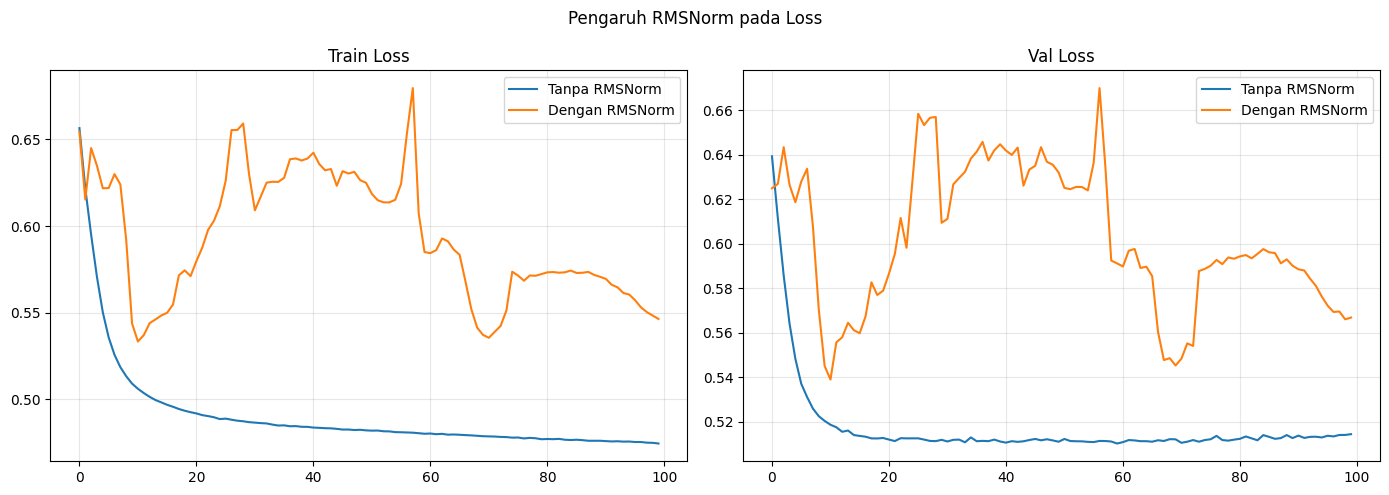


Rangkuman Akurasi Akhir
Tanpa RMSNorm: Train=0.7630, Val=0.7455
Dengan RMSNorm: Train=0.7218, Val=0.7070
Tanpa RMSNorm


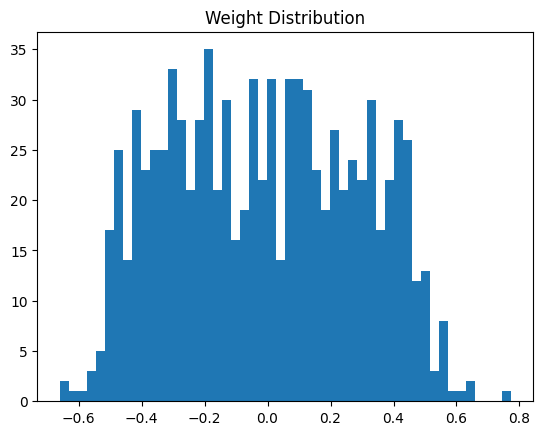

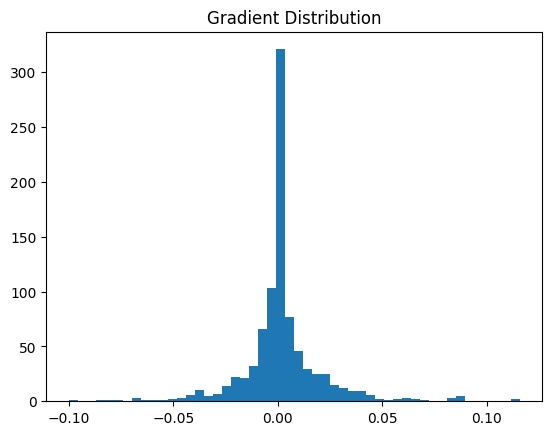

Dengan RMSNorm


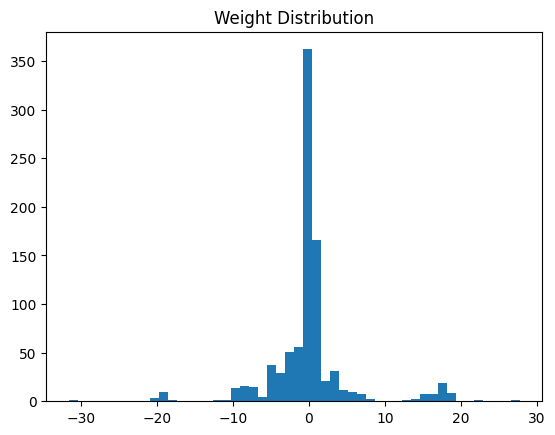

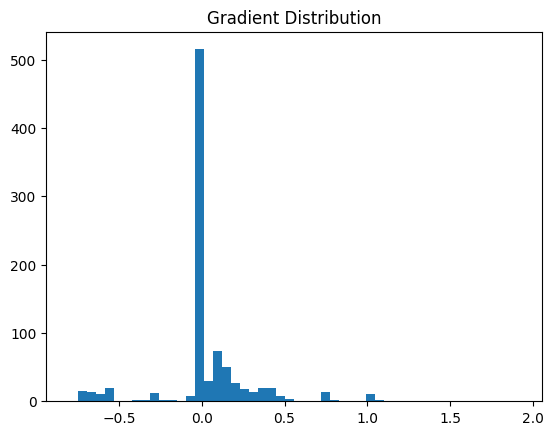

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in norm_results.items():
    axes[0].plot(res['history']['train_loss'], label=name)
    axes[1].plot(res['history']['val_loss'], label=name)
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Pengaruh RMSNorm pada Loss')
plt.tight_layout()
plt.show()

print('\nRangkuman Akurasi Akhir')
for name, res in norm_results.items():
    print(f'{name}: Train={res["train_acc"]:.4f}, Val={res["val_acc"]:.4f}')

for name, res in norm_results.items():
    print(name)
    res['model'].plot_weight_distribution()
    res['model'].plot_gradient_distribution()
